<a href="https://colab.research.google.com/github/k2herat/basic_ml_hse/blob/task_6/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22homework_06_CNN%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Основы машинного обучения, ПАДиИИ

## НИУ ВШЭ, 2024-25 учебный год

# Домашнее задание 6: Классификация при помощи CNN

Задание выполнил(а):

    Алметов Кирилл
    

## Общая информация

__Внимание!__  


* Домашнее задание выполняется самостоятельно
* Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов
* Использование в решении домашнего задания генеративных моделей (ChatGPT и так далее) за рамками справочной и образовательной информации для генерации кода задания — считается плагиатом, и такое домашнее задание оценивается в 0 баллов
* Старайтесь сделать код как можно более оптимальным. Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

## О задании

В этом задании вам предстоит познакомиться со сверточными сетями и их обучением для классификации изображений с использованием библиотеки PyTorch.


## Импорт библиотек

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from sklearn.model_selection import train_test_split

## 0. Загрузка данных

Работать мы будем с набором данных [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html). CIFAR10 представляет собой набор изображений 32х32 пикселя, разделенных на 10 классов.

![title](https://pytorch.org/tutorials/_images/cifar10.png)




Набор данных уже определен в <code>torchvision.datasets</code>, так что возьмем его оттуда.



In [2]:
# Для тру нормализации
# mean = [0.4914, 0.4822, 0.4465]
# std = [0.2470, 0.2435, 0.2616]
# Тут взяты значения как в одном из туториалов пайторча :)


def get_cifar10_data(batch_size, transform_train):
    torch.manual_seed(0)
    np.random.seed(0)

    transform_test = transforms.Compose(
        [
            transforms.ToTensor(),
            # Переводим цвета пикселей в отрезок [-1, 1]
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ]
    )

    # Загружаем данные
    trainvalset = torchvision.datasets.CIFAR10(
        root="./data", train=True, download=True, transform=transform_train
    )
    testset = torchvision.datasets.CIFAR10(
        root="./data", train=False, download=True, transform=transform_test
    )

    # В датасете определено разбиение только на train и test,
    # так что валидацию дополнительно выделяем из обучающей выборки
    train_idx, valid_idx = train_test_split(
        np.arange(len(trainvalset)), test_size=0.3, shuffle=True, random_state=0
    )
    trainset = torch.utils.data.Subset(trainvalset, train_idx)
    valset = torch.utils.data.Subset(trainvalset, valid_idx)

    train_loader = torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, shuffle=True, num_workers=2
    )
    val_loader = torch.utils.data.DataLoader(
        valset, batch_size=batch_size, shuffle=False, num_workers=2
    )
    test_loader = torch.utils.data.DataLoader(
        testset, batch_size=batch_size, shuffle=False, num_workers=2
    )

    return train_loader, val_loader, test_loader

In [3]:
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(
    batch_size=64, transform_train=transform
)

100%|██████████| 170M/170M [00:29<00:00, 5.73MB/s]


Посмотрим на изображения:

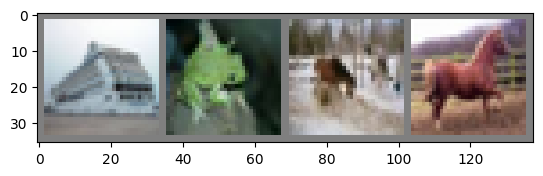

ship frog horse horse


In [4]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(train_loader)
images, labels = dataiter.__next__()

imshow(torchvision.utils.make_grid(images[:4]))

classes = (
    "plane",
    "car",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)
print(*[classes[labels[i]] for i in range(4)])

## 1. Задание сверточной сети (3 балла)

Теперь нам нужно задать сверточную нейронную сеть, которую мы будем обучать классифицировать изображения.

Используем сеть, основанную на одном блоке архитектуры, похожей на ResNet. Обратите внимание, это не ResNet 1 в 1.

<img src="https://i.ibb.co/2hg962h/basic-block.png" width="500"/>

__Указания:__

- Все сверточные слои должны иметь 32 выходных канала, а также не должны изменять ширину и высоту изображения.
- Выход блока сократите до размерности 32х4х4, применив average pooling.
- Для получения итоговых логитов, распрямите выход пулинга в вектор из 512 элементов, а затем пропустите его через линейный слой.

**Задание 1.1 (3 балла).**

Определите архитектуру сети соответственно схеме и указаниям выше.

Ключевые слова: <code>Conv2d</code>, <code>BatchNorm2d</code>, <code>AvgPool2d</code>.

In [6]:
n_classes = 10


class BasicBlockNet(nn.Module):
    def __init__(self, num_classes=10):
        super(BasicBlockNet, self).__init__()

        self.initial_conv = nn.Conv2d(3, 32, kernel_size=3, padding=1)

        self.conv_layer1 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.batch_norm1 = nn.BatchNorm2d(32)
        self.activation = nn.ReLU(inplace=True)
        self.conv_layer2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.batch_norm2 = nn.BatchNorm2d(32)


        self.shortcut_layer = nn.Conv2d(32, 32, kernel_size=1)


        self.pooling_layer = nn.AdaptiveAvgPool2d((4, 4))


        self.fc = nn.Linear(32 * 4 * 4, num_classes)

    def forward(self, x):

        x = self.initial_conv(x)

        identity = self.shortcut_layer(x)


        out = self.conv_layer1(x)
        out = self.batch_norm1(out)
        out = self.activation(out)
        out = self.conv_layer2(out)
        out = self.batch_norm2(out)


        out += identity
        out = self.activation(out)


        out = self.pooling_layer(out)
        out = torch.flatten(out, start_dim=1)
        out = self.fc(out)

        return out


In [7]:
net = BasicBlockNet()
net

BasicBlockNet(
  (initial_conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_layer1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batch_norm1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (activation): ReLU(inplace=True)
  (conv_layer2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batch_norm2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (shortcut_layer): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  (pooling_layer): AdaptiveAvgPool2d(output_size=(4, 4))
  (fc): Linear(in_features=512, out_features=10, bias=True)
)

Проверим, что выход сети имеет корректную размерность:

In [8]:
assert net(torch.zeros((10, 3, 32, 32))).shape == (10, 10)

Чтобы проводить вычисления на GPU, в PyTorch необходимо руками перекладывать объекты, с которыми вы хотите проводить вычисления, на графический ускоритель. Это делается следующим образрм:

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [10]:
net = net.to(device)

Подключение GPU в google.colab:

**Среда выполнения** -> **Сменить среду выполнения** -> **Аппаратный ускоритель** -> **GPU**

## 2. Обучение и тестирование модели (3 балла)

**Задание 2.1 (2 балла).** Переходим к обучению модели. Заполните пропуски в функциях <code>test</code> и <code>train_epoch</code>. В качестве функции потерь будем использовать [кросс-энтропию](https://pytorch.org/docs/stable/generated/torch.nn.functional.cross_entropy.html), а в качестве метрики качества accuracy.

In [11]:
import numpy as np
import torch
import torch.nn.functional as F

def test(model, loader):
    loss_log = []
    acc_log = []
    model.eval()

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(model.fc.weight.device), target.to(model.fc.weight.device)

            output = model(data)
            loss = F.cross_entropy(output, target)

            loss_log.append(loss.item())


            pred = output.argmax(dim=1)
            acc = (pred == target).float().mean()
            acc_log.append(acc.item())

    return np.mean(loss_log), np.mean(acc_log)


def train_epoch(model, optimizer, train_loader):
    loss_log = []
    acc_log = []
    model.train()

    for data, target in train_loader:
        data, target = data.to(model.fc.weight.device), target.to(model.fc.weight.device)

        optimizer.zero_grad()
        output = model(data)
        loss = F.cross_entropy(output, target)

        loss.backward()
        optimizer.step()

        loss_log.append(loss.item())
        pred = output.argmax(dim=1)
        acc = (pred == target).float().mean()
        acc_log.append(acc.item())

    return loss_log, acc_log


def train(model, optimizer, n_epochs, train_loader, val_loader, scheduler=None):
    train_loss_log, train_acc_log, val_loss_log, val_acc_log = [], [], [], []

    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(model, optimizer, train_loader)
        val_loss, val_acc = test(model, val_loader)

        train_loss_log.extend(train_loss)
        train_acc_log.extend(train_acc)

        val_loss_log.append(val_loss)
        val_acc_log.append(val_acc)

        print(f"Epoch {epoch + 1}/{n_epochs}")
        print(f" train loss: {np.mean(train_loss):.4f}, train acc: {np.mean(train_acc):.4f}")
        print(f" val loss: {val_loss:.4f}, val acc: {val_acc:.4f}\n")

        if scheduler is not None:
            scheduler.step()

    return train_loss_log, train_acc_log, val_loss_log, val_acc_log

Запустим обучение модели. В качестве оптимизатора будем использовать стохастический градиентный спуск, который является де-факто стандартом в задачах компьютерного зрения (наравне с <code>Adam</code>).

__Замечание:__ Для достижения наилучшего качества в нашем случае потребуется обучать модель несколько сотен эпох. Однако в целях экономии вашего времени и сил, во всех экспериментах мы ограничимся 20 эпохами.

In [12]:
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
train_loss_log, train_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader
)

Epoch 1/20
 train loss: 1.4830, train acc: 0.4682
 val loss: 1.2374, val acc: 0.5663

Epoch 2/20
 train loss: 1.1470, train acc: 0.5992
 val loss: 1.0573, val acc: 0.6365

Epoch 3/20
 train loss: 1.0533, train acc: 0.6375
 val loss: 1.0338, val acc: 0.6443

Epoch 4/20
 train loss: 0.9899, train acc: 0.6549
 val loss: 1.0082, val acc: 0.6525

Epoch 5/20
 train loss: 0.9430, train acc: 0.6744
 val loss: 1.0352, val acc: 0.6471

Epoch 6/20
 train loss: 0.9160, train acc: 0.6823
 val loss: 0.9364, val acc: 0.6790

Epoch 7/20
 train loss: 0.8888, train acc: 0.6906
 val loss: 0.9574, val acc: 0.6699

Epoch 8/20
 train loss: 0.8687, train acc: 0.7000
 val loss: 0.8968, val acc: 0.6901

Epoch 9/20
 train loss: 0.8378, train acc: 0.7105
 val loss: 0.9592, val acc: 0.6695

Epoch 10/20
 train loss: 0.8219, train acc: 0.7161
 val loss: 0.9226, val acc: 0.6900

Epoch 11/20
 train loss: 0.7955, train acc: 0.7221
 val loss: 0.9296, val acc: 0.6824

Epoch 12/20
 train loss: 0.7828, train acc: 0.7284
 

Посчитайте точность на тестовой выборке:

In [13]:
loss_log, acc_log = test(net, test_loader)
print("Loss func:", loss_log)
print("Accuracy:", acc_log)

Loss func: 0.8810598155495467
Accuracy: 0.7024283439490446


Если вы все сделали правильно, у вас должна была получиться точность $\ge 67\%$.

**Задание 2.2 (1 балл).** Постройте графики зависимости функции потерь и точности классификации от номера шага оптимизатора. На каждом графике расположите данные и для обучающей и для валидационной выборки, итого у вас должно получиться два графика. Обратите внимание, что на обучающей выборке эти данные считаются по каждому батчу, на валидационной же они считаются по всей выборке раз в эпоху.

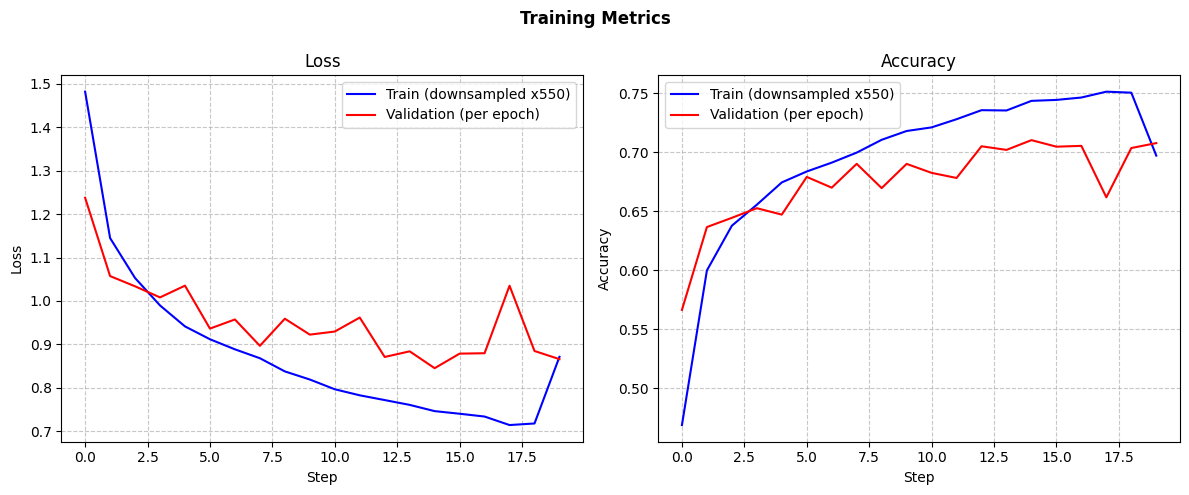

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def downsample_log(data: np.ndarray, window_size: int) -> np.ndarray:

    n = len(data)
    num_windows = n // window_size
    result = []


    for i in range(num_windows):
        start = i * window_size
        result.append(np.mean(data[start:start+window_size]))


    if remainder_start := num_windows * window_size < n:
        result.append(np.mean(data[remainder_start:]))

    return np.array(result)


WINDOW_SIZE = 550
train_loss_downsampled = downsample_log(np.array(train_loss_log), WINDOW_SIZE)
train_acc_downsampled = downsample_log(np.array(train_acc_log), WINDOW_SIZE)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Training Metrics', fontweight='bold')


ax1.plot(train_loss_downsampled, 'b-', label=f'Train (downsampled x{WINDOW_SIZE})')
ax1.plot(val_loss_log, 'r-', label='Validation (per epoch)')
ax1.set(xlabel='Step', ylabel='Loss', title='Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)


ax2.plot(train_acc_downsampled, 'b-', label=f'Train (downsampled x{WINDOW_SIZE})')
ax2.plot(val_acc_log, 'r-', label='Validation (per epoch)')
ax2.set(xlabel='Step', ylabel='Accuracy', title='Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Adjust space for suptitle
plt.show()

## 3. Расписание длины шага (2 балла)

С курса "Машинное обучение" вы уже должны знать, что сходимость стохастического градиентного спуска мы можем теоретически гарантировать только если будем определенным образом со временем уменьшать длину шага. На практике при обучении нейронных сетей такая техника оказывается очень полезной, однако теоретически обоснованными способами уменьшения длины шага фантазия не ограничивается.

Одним из простейших способов является кусочно постоянная функция: на нескольких фиксированных эпохах уменьшаем длину шага в константу раз.

In [18]:
net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader, scheduler
)

Epoch 1/20
 train loss: 1.5575, train acc: 0.4465
 val loss: 1.2807, val acc: 0.5534

Epoch 2/20
 train loss: 1.1858, train acc: 0.5847
 val loss: 1.0992, val acc: 0.6165

Epoch 3/20
 train loss: 1.0717, train acc: 0.6281
 val loss: 1.0399, val acc: 0.6390

Epoch 4/20
 train loss: 1.0007, train acc: 0.6520
 val loss: 1.0064, val acc: 0.6518

Epoch 5/20
 train loss: 0.9573, train acc: 0.6697
 val loss: 1.0215, val acc: 0.6496

Epoch 6/20
 train loss: 0.9266, train acc: 0.6814
 val loss: 0.9661, val acc: 0.6673

Epoch 7/20
 train loss: 0.8872, train acc: 0.6948
 val loss: 1.0214, val acc: 0.6420

Epoch 8/20
 train loss: 0.8794, train acc: 0.6948
 val loss: 0.9635, val acc: 0.6723

Epoch 9/20
 train loss: 0.8518, train acc: 0.7061
 val loss: 0.9219, val acc: 0.6875

Epoch 10/20
 train loss: 0.8351, train acc: 0.7115
 val loss: 0.9207, val acc: 0.6841

Epoch 11/20
 train loss: 0.7008, train acc: 0.7577
 val loss: 0.7872, val acc: 0.7301

Epoch 12/20
 train loss: 0.6799, train acc: 0.7658
 

Посчитайте точность на тестовой выборке:

In [19]:
loss_log, acc_log = test(net, test_loader)
print("Loss func:", loss_log)
print("Accuracy:", acc_log)

Loss func: 0.785655628913527
Accuracy: 0.7307921974522293


**Задание 3.0 (0.5 баллов).** Здесь может возникнуть вопрос: а что будет, если мы не будем уменьшать длину шага в процессе обучения, а сразу возьмем констатную, равную значению нашей кусочно-постоянной функции на последних эпохах, то есть $0.001$ в нашем случае. Запустите обучение и проверьте, что в таком случае мы получим худшее качество на тестовой выборке.

In [20]:
net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader
)

Epoch 1/20
 train loss: 1.7833, train acc: 0.3729
 val loss: 1.5578, val acc: 0.4457

Epoch 2/20
 train loss: 1.4814, train acc: 0.4761
 val loss: 1.4005, val acc: 0.5007

Epoch 3/20
 train loss: 1.3673, train acc: 0.5154
 val loss: 1.3648, val acc: 0.5153

Epoch 4/20
 train loss: 1.2935, train acc: 0.5455
 val loss: 1.2627, val acc: 0.5564

Epoch 5/20
 train loss: 1.2289, train acc: 0.5703
 val loss: 1.2065, val acc: 0.5766

Epoch 6/20
 train loss: 1.1713, train acc: 0.5892
 val loss: 1.1347, val acc: 0.6023

Epoch 7/20
 train loss: 1.1191, train acc: 0.6129
 val loss: 1.0798, val acc: 0.6269

Epoch 8/20
 train loss: 1.0693, train acc: 0.6311
 val loss: 1.1149, val acc: 0.6080

Epoch 9/20
 train loss: 1.0318, train acc: 0.6458
 val loss: 1.0173, val acc: 0.6512

Epoch 10/20
 train loss: 1.0027, train acc: 0.6538
 val loss: 0.9924, val acc: 0.6561

Epoch 11/20
 train loss: 0.9796, train acc: 0.6632
 val loss: 0.9905, val acc: 0.6612

Epoch 12/20
 train loss: 0.9590, train acc: 0.6688
 

In [21]:
loss_log, acc_log = test(net, test_loader)
print("Loss func:", loss_log)
print("Accuracy:", acc_log)

Loss func: 0.8725093155150201
Accuracy: 0.6971536624203821


**Задание 3.1 (1.5 балла).** Изучите, какие еще способы уменьшения длины шага представлены в <code>torch.optim.lr_scheduler</code>. Выберите несколько из них, объясните, как они устроены, и обучите модель с ними. Удалось ли добиться улучшения качества на тестовой выборке?


=== Training with StepLR scheduler ===
Epoch 1/20
 train loss: 1.4979, train acc: 0.4628
 val loss: 1.2513, val acc: 0.5601

Epoch 2/20
 train loss: 1.1597, train acc: 0.5993
 val loss: 1.2030, val acc: 0.5722

Epoch 3/20
 train loss: 1.0449, train acc: 0.6364
 val loss: 1.0168, val acc: 0.6471

Epoch 4/20
 train loss: 0.9810, train acc: 0.6610
 val loss: 0.9818, val acc: 0.6638

Epoch 5/20
 train loss: 0.9421, train acc: 0.6712
 val loss: 1.0186, val acc: 0.6528

Epoch 6/20
 train loss: 0.8347, train acc: 0.7127
 val loss: 0.8833, val acc: 0.6999

Epoch 7/20
 train loss: 0.8170, train acc: 0.7170
 val loss: 0.9073, val acc: 0.6932

Epoch 8/20
 train loss: 0.7953, train acc: 0.7252
 val loss: 0.8401, val acc: 0.7094

Epoch 9/20
 train loss: 0.7846, train acc: 0.7293
 val loss: 0.8700, val acc: 0.6978

Epoch 10/20
 train loss: 0.7680, train acc: 0.7330
 val loss: 0.9435, val acc: 0.6843

Epoch 11/20
 train loss: 0.7134, train acc: 0.7542
 val loss: 0.8258, val acc: 0.7157

Epoch 12/20


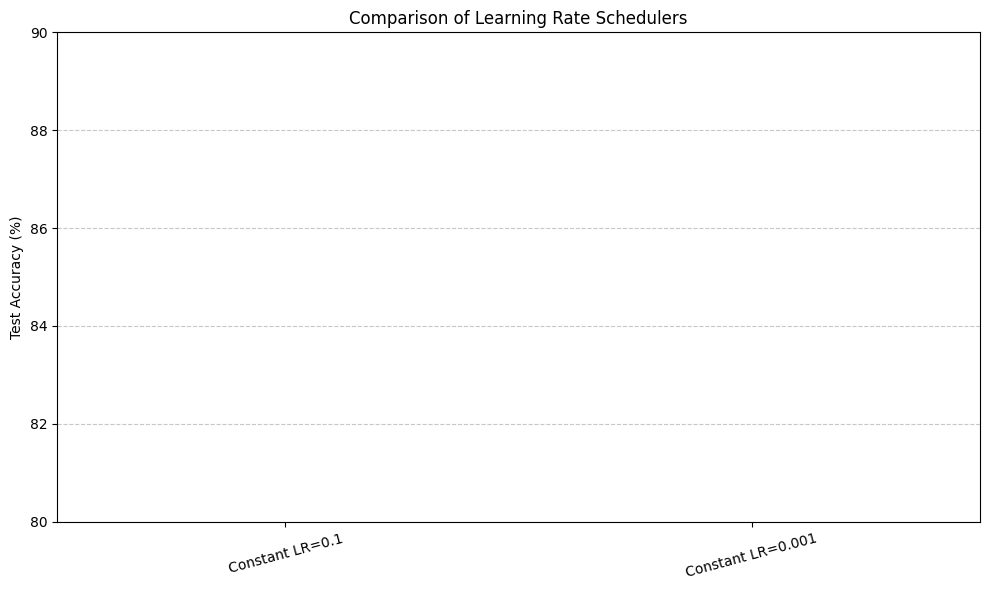

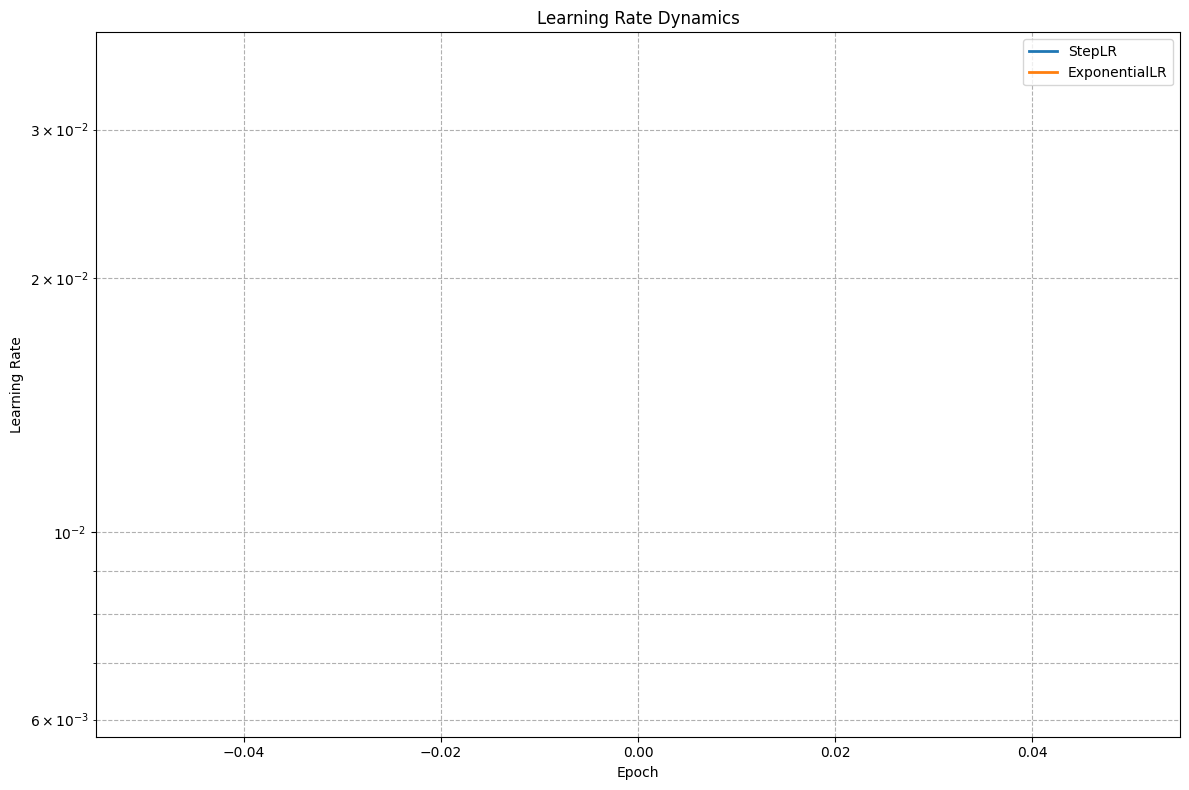

In [23]:
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, ExponentialLR


schedulers_config = {
    "StepLR": (StepLR, {'step_size': 5, 'gamma': 0.5}),
    "ExponentialLR": (ExponentialLR, {'gamma': 0.95}),
}


results = {}
lr_histories = {}


for name, (scheduler_cls, params) in schedulers_config.items():
    print(f"\n=== Training with {name} scheduler ===")

    net = BasicBlockNet().to(device)
    optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)


    scheduler = scheduler_cls(optimizer, **params)

    tr_loss, tr_acc, val_loss, val_acc = train(
        net, optimizer, 20, train_loader, val_loader, scheduler
    )


    lr_histories[name] = [group['lr'] for group in optimizer.param_groups]


    loss_log, acc_log = test(net, test_loader)
    print("Loss func:", loss_log)
    print("Accuracy:", acc_log)


for lr in [0.1, 0.001]:
    net = BasicBlockNet().to(device)
    optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
    _, _, _, _ = train(net, optimizer, 20, train_loader, val_loader)
    loss_log, acc_log = test(net, test_loader)
    results[f"Constant LR={lr}"] = acc_log

plt.figure(figsize=(10, 6))
methods, accuracies = zip(*results.items())
plt.bar(methods, [acc*100 for acc in accuracies])
plt.ylabel('Test Accuracy (%)')
plt.title('Comparison of Learning Rate Schedulers')
plt.ylim(80, 90)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 8))
for name, lrs in lr_histories.items():
    plt.plot(lrs, label=name, lw=2)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Dynamics')
plt.yscale('log')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()

Your answers here:  
...

## 4. Аугментации данных (2 балла)

Еще одной стандартной техникой, применяющейся в глубинном обучении, а особенно часто в компьютерном зрении, являются аугментации данных. Суть аугментаций состоит в том, что мы можем некоторым синтетическим образом видоизменять объекты обучающей выборки, тем самым расширяя ее, а также делая итоговую модель более устойчивой к таким изменениям.

Простейшая аугментация, которую можно применить к картинкам — разворот картинки по горизонтальной оси. То есть при обучении модели с вероятностью $0.5$ мы будем разворачивать картинку из обучающей выборки.

In [24]:
dataiter = iter(train_loader)
images, labels = dataiter.next()

imshow(torchvision.utils.make_grid(images[:4]))

imshow(torchvision.utils.make_grid(transforms.functional.hflip(images[:4])))

AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute 'next'

Наиболее удобным способом работы с аугментациями в PyTorch является их задание в списке <code>transforms</code>, который затем передается в загрузчик данных. Обучим нашу сеть, применяя горизонтальные повороты:

In [ ]:
transform = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

train_loader, val_loader, test_loader = get_cifar10_data(
    batch_size=64, transform_train=transform
)

net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader, scheduler
)

Посчитайте точность на тестовой выборке:

In [ ]:
# <your code here>

**Задание 4.1 (2 балла).** Изучите, какие еще способы аугментаций изображений представлены в <code>torchvision.transforms</code>. Выберите несколько из них, объясните, как они устроены, и обучите модель с ними (по отдельности и вместе). Удалось ли добиться улучшения качества на тестовой выборке?

In [ ]:
# <your code here>

Your answers here:

## Бонус. Логирование в wandb (1 балл)

На практике специалиста по глубинному обучению часто встречаются ситуации, когда нейросеть учится на каком-то удаленном сервере. И обычно вам хочется отслеживать прогресс обучения, особенно когда время обучения модели исчисляется днями или неделями. Для таких целей существует несколько инструментов. Вероятно, самый популярный из них — [wandb](https://wandb.ai/site).

Ваша задача состоит в том, чтобы разобраться как им пользоваться, и повторить задания 2.1 и 2.2 с его использованием. Обучение вы можете запускать в этом же ноутбуке, но теперь вам необходимо через wandb логировать значения функции потерь и точности на обучающей выборке и на валидационной. Результатом работы должны быть ваш код и публичная ссылка на страничку с графиками, идентичными графикам в задании 2.2.

Если вас смущает, что WandB грозится забанить вас, то можете разобраться с любым его аналогом и приложить ссылку на аналог.

In [ ]:
# <your code here>

Ссылка на страницу с графиками:

    (...)